In [1]:
# this notebook contains a lot of ML training/testing/validation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import boto3
import pyarrow.parquet as pq
import seaborn as sns
import lightgbm as lgb

# sklearn
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score, accuracy_score, confusion_matrix, classification_report, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.inspection import permutation_importance

In [2]:
s3 = boto3.client('s3')
df = pd.read_parquet('s3://processed-data-809918852303-us-east-1-an/mint_merged_df_7days_FULL.parquet')

In [3]:
df = df.drop(columns=['state', 'zone_id', 'name', 'model_run_date'])
df = df.sort_values(by="date").reset_index(drop=True)

In [4]:
# extracting year for each row
df['date'] = pd.to_datetime(df['date'])
df['day_number'] = df['date'].dt.dayofyear
df['year'] = df['date'].dt.year

In [5]:
# get the max week present in the data for each year
max_weeks = df.groupby('year')['week'].transform('max')

# if not 52 or 53 default to 52
max_weeks = np.where(max_weeks.isin([52, 53]), max_weeks, 52)

# decompose discrete week into cont. sin/cos component
df['week_sin'] = np.sin(2 * np.pi * df['week'] / max_weeks)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / max_weeks)

df = df.drop(columns=['year'])

In [7]:
#create boolean masks for differences outside of 2°F, 3°F, 4°F, and 5°F 
mask_2F = (df['nbm_minus_obs'] <= -2)
df['outside_-2F'] = mask_2F

mask_3F = (df['nbm_minus_obs'] <= -3)
df['outside_-3F'] = mask_3F

mask_4F = (df['nbm_minus_obs'] <= -4)
df['outside_-4F'] = mask_4F

mask_5F = (df['nbm_minus_obs'] <= -5)
df['outside_-5F'] = mask_5F

mask_2F = (df['nbm_minus_obs'] >= 2)
df['outside_2F'] = mask_2F

mask_3F = (df['nbm_minus_obs'] >= 3)
df['outside_3F'] = mask_3F

mask_4F = (df['nbm_minus_obs'] >= 4)
df['outside_4F'] = mask_4F

mask_5F = (df['nbm_minus_obs'] >= 5)
df['outside_5F'] = mask_5F

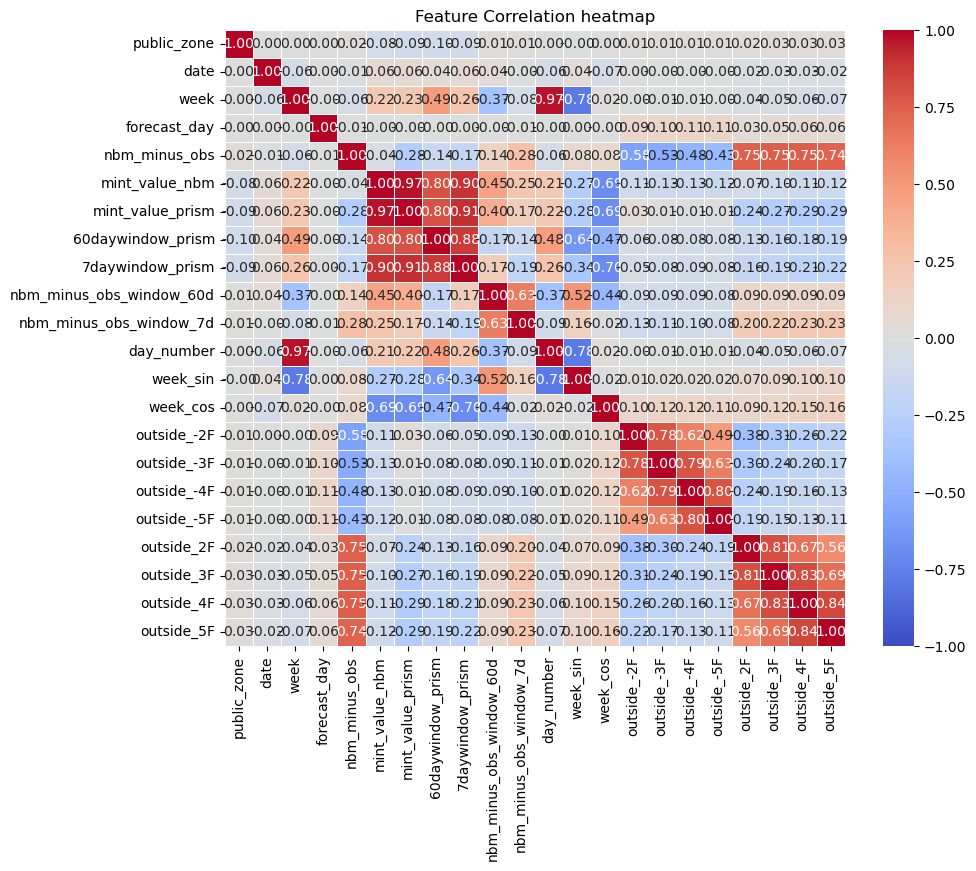

In [8]:
# viewing feature correlations to see how each variable relates to another
corr_matrix = df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation heatmap")
plt.show()

In [8]:
df

,public_zone,date,week,forecast_day,nbm_minus_obs,mint_value_nbm,mint_value_prism,60daywindow_prism,7daywindow_prism,nbm_minus_obs_window_60d,...,week_sin,week_cos,outside_-2F,outside_-3F,outside_-4F,outside_-5F,outside_2F,outside_3F,outside_4F,outside_5F
0,1,2020-10-21,43,1,2.655380,59.489726,56.834346,58.933126,45.827951,0.556600,...,-0.92669,0.375828,False,False,False,False,True,False,False,False
1,273,2020-10-21,43,1,2.013299,53.445104,51.431805,53.831922,53.851795,-0.386819,...,-0.92669,0.375828,False,False,False,False,True,False,False,False
2,2830,2020-10-21,43,1,3.412402,53.326531,49.914129,48.214410,38.247817,5.112120,...,-0.92669,0.375828,False,False,False,False,True,True,False,False
3,2831,2020-10-21,43,1,0.738916,53.275362,52.536446,49.967983,39.156013,3.307379,...,-0.92669,0.375828,False,False,False,False,False,False,False,False
4,2832,2020-10-21,43,1,1.920882,54.138889,52.218007,49.899726,38.735513,4.239163,...,-0.92669,0.375828,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65680995,2566,2026-07-18,29,7,-1.422953,67.784530,69.207484,61.975988,67.657378,5.808543,...,-0.354605,-0.935016,False,False,False,False,False,False,False,False
65680996,2567,2026-07-18,29,1,4.736520,73.614035,68.877515,62.648676,68.876680,10.965359,...,-0.354605,-0.935016,False,False,False,False,True,True,True,False
65680997,2567,2026-07-18,29,2,4.666345,73.543860,68.877515,62.648676,68.876680,10.895183,...,-0.354605,-0.935016,False,False,False,False,True,True,True,False
65680998,2563,2026-07-18,29,6,-1.235176,68.675978,69.911154,60.944367,66.563924,7.731611,...,-0.354605,-0.935016,False,False,False,False,False,False,False,False


In [10]:
# defining proportions!!!
train_ratio = 0.72
val_ratio = 0.14

total_rows = len(df)
val_split_idx = int(total_rows * train_ratio)
test_split_idx = int((total_rows * (train_ratio + val_ratio)))

val_cutoff = df.iloc[[df.index[val_split_idx]]]
val_cutoff = val_cutoff['date'].iloc[0].date()
val_cutoff = pd.to_datetime(val_cutoff)

test_cutoff = df.iloc[[df.index[test_split_idx]]]
test_cutoff = test_cutoff['date'].iloc[0].date()
test_cutoff = pd.to_datetime(test_cutoff)

#time based splitting here
train_df = df[df['date'] <= val_cutoff]
val_df = df[df['date'] <= test_cutoff]
val_df = val_df[val_df['date'] > val_cutoff]
test_df = df[df['date'] > test_cutoff]

print(f"Train window: '{train_df['date'].min()}' to '{train_df['date'].max()}'")
print(f"Val window:   '{val_df['date'].min()}' to '{val_df['date'].max()}'")
print(f"Test window:  '{test_df['date'].min()}' to '{test_df['date'].max()}'")

Train window: '2020-10-21 00:00:00' to '2025-06-30 00:00:00'
Val window:   '2025-07-01 00:00:00' to '2025-12-20 00:00:00'
Test window:  '2025-12-21 00:00:00' to '2026-07-18 00:00:00'


In [11]:
num_list = [-2, 2, -3, 3, -4, 4, -5, 5]

for i in num_list:
    string=f"outside_{i}F"
    mask = (train_df.loc[train_df[string]==True, 'nbm_minus_obs_window_60d'])
    print(f"train_df vals outside {i}F: {mask.count()/len(train_df[string])*100:.3f}%")
    
    mask = (val_df.loc[val_df[string]==True, 'nbm_minus_obs_window_60d'])
    print(f"val_df vals outside {i}F: {mask.count()/len(val_df[string])*100:.3f}%")
    
    mask = (test_df.loc[test_df[string]==True, 'nbm_minus_obs_window_60d'])
    print(f"test_years vals outside {i}F: {mask.count()/len(test_df[string])*100:.3f}%\n")

train_df vals outside -2F: 14.709%
val_df vals outside -2F: 12.839%
test_years vals outside -2F: 16.399%

train_df vals outside 2F: 46.383%
val_df vals outside 2F: 41.367%
test_years vals outside 2F: 48.765%

train_df vals outside -3F: 9.503%
val_df vals outside -3F: 7.901%
test_years vals outside -3F: 11.182%

train_df vals outside 3F: 36.535%
val_df vals outside 3F: 30.323%
test_years vals outside 3F: 39.564%

train_df vals outside -4F: 6.107%
val_df vals outside -4F: 4.956%
test_years vals outside -4F: 7.522%

train_df vals outside 4F: 28.260%
val_df vals outside 4F: 21.895%
test_years vals outside 4F: 31.504%

train_df vals outside -5F: 3.938%
val_df vals outside -5F: 3.158%
test_years vals outside -5F: 5.043%

train_df vals outside 5F: 21.611%
val_df vals outside 5F: 15.777%
test_years vals outside 5F: 24.809%



In [12]:
# Input features
features = [
    'public_zone',                            # 1-3850
    'week_sin',
    'week_cos',
    'forecast_day',                           # 1-7 
    'nbm_minus_obs_window_7d',                # 7-day averaged window
    'nbm_minus_obs_window_60d'                # 60-day averaged window
]
# 3 binary targets
target_columns = [
    'outside_-2F', 
    'outside_2F', 
    'outside_-3F',
    'outside_3F',
    'outside_-4F', 
    'outside_4F', 
    'outside_-5F', 
    'outside_5F']

# getting features to the right data types for LGBM

df['public_zone']          = df['public_zone'].astype('category')
df['week_sin']             = df['week_sin'].astype(float)
df['week_cos']             = df['week_cos'].astype(float)
df['forecast_day']         = df['forecast_day'].astype('category')
df['nbm_minus_obs_window_7d'] = df['nbm_minus_obs_window_7d'].astype(float)
df['nbm_minus_obs_window_60d'] = df['nbm_minus_obs_window_60d'].astype(float)

In [13]:
def create_multiclass_target(error_series, threshold=2.0):
    conditions = [
        (error_series <= -threshold),                  #underforecast
        (error_series >= threshold)                    # overforecast
    ]
    choices = [2, 1]
    return np.select(conditions, choices, default=0) #we're good

y_train = create_multiclass_target(train_df['nbm_minus_obs'], 2)
y_val = create_multiclass_target(val_df['nbm_minus_obs'], 2)
y_test = create_multiclass_target(test_df['nbm_minus_obs'], 2)


In [14]:
class_num = 3

X_train = train_df[features]
y_train = create_multiclass_target(train_df['nbm_minus_obs'], threshold=class_num)
X_val = val_df[features]
y_val = create_multiclass_target(val_df['nbm_minus_obs'], threshold=class_num)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weight_dict = dict(zip(classes, weights))
class_weight_dict # class weights available !!!

{np.int64(0): np.float64(0.5078811224182361),
 np.int64(1): np.float64(1.1795040477867071),
 np.int64(2): np.float64(5.4578794773619235)}

LightGBM

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.155640 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4372
[LightGBM] [Info] Number of data points in the train set: 47301100, number of used features: 6
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[170]	valid_0's auc_mu: 0.777759
Overall Model Accuracy: 0.5848

--- LIGHTGBM VALIDATION RESULTS ---
                   precision    recall  f1-score   supp

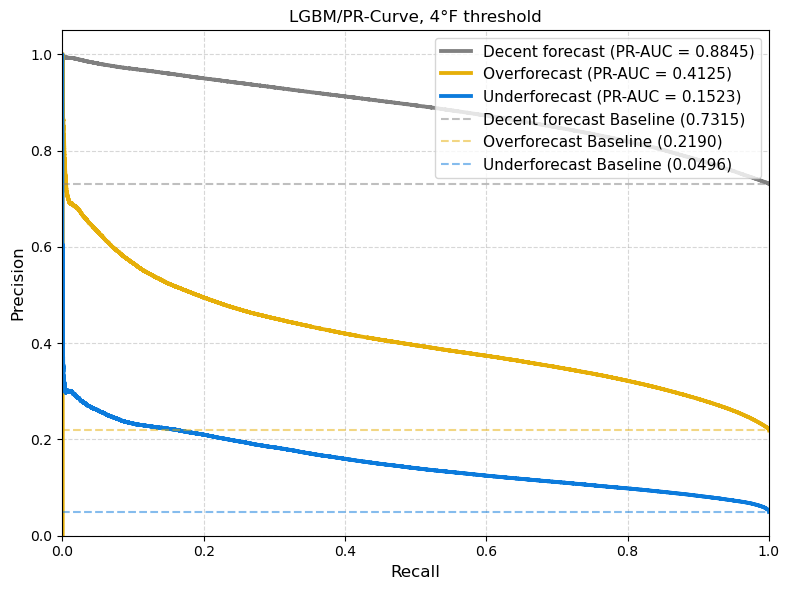

In [15]:
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    metric='auc_mu',
    num_class=3,
    num_leaves=45,
    n_estimators=1000,       
    learning_rate=0.05,
    max_depth=12,   
    min_child_samples=500,
    max_bins=255,
    max_bin_by_feature=[255, 32, 32, 7, 255, 255],
    class_weight='balanced',
    n_jobs=-1,          
    random_state=42,
)

lgb_model.fit(X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

y_val_pred = lgb_model.predict(X_val)
y_val_prob = lgb_model.predict_proba(X_val)

acc = accuracy_score(y_val, y_val_pred)
print(f"Overall Model Accuracy: {acc:.4f}")

print("\n--- LIGHTGBM VALIDATION RESULTS ---")
print(classification_report(y_val, y_val_pred, target_names=['Decent Forecast', 'Off overforecast', 'Off underforecast']))

#plotting
classes = [0, 1, 2]
colors = ['grey', '#e6af09', '#0c7bdc', 'grey']
target_names = ['Decent forecast', 'Overforecast', 'Underforecast']
y_val_binarized = label_binarize(y_val, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve(y_val_binarized[:, i], y_val_prob[:, i])
    
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.4f})', linewidth=2.75, color=colors[i])

# baseline reference line
for i in range(len(classes)):
    prevalence = y_val_binarized[:, i].mean()
    plt.axhline(
        y=prevalence, 
        linestyle='--', 
        color=colors[i],
        alpha=0.5,
        label=f'{target_names[i]} Baseline ({prevalence:.4f})'
    )
    
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'LGBM/PR-Curve, {class_num}°F threshold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
#plt.savefig(f'minT-{class_num}F-lgbm-pr-auc-final.png')
#plt.savefig(f'with_7daywindow_{class_num}F-minT-lgbm-pr-auc.png')
plt.show()

In [16]:
# get both importance types
split_importance = lgb_model.booster_.feature_importance(importance_type='split')
gain_importance = lgb_model.booster_.feature_importance(importance_type='gain')
feature_names = X_train.columns

# build combined df
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Split (Frequency)': split_importance,
    'Gain (Impact)': gain_importance
})

# normalize them to percentages so easy to compare
df_imp['Split %'] = (df_imp['Split (Frequency)'] / df_imp['Split (Frequency)'].sum()) * 100
df_imp['Gain %'] = (df_imp['Gain (Impact)'] / df_imp['Gain (Impact)'].sum()) * 100

# sort by gain to see what drives predictions, should likely be public zone with highest split however
df_imp = df_imp.sort_values(by='Gain %', ascending=False)
print(df_imp[['Feature', 'Gain %', 'Split %']].to_string(index=False))

                 Feature    Gain %   Split %
 nbm_minus_obs_window_7d 28.571087 10.396613
             public_zone 24.035851 51.109626
                week_cos 21.579909 12.869875
            forecast_day 14.492111  4.598930
                week_sin  8.186359 12.424242
nbm_minus_obs_window_60d  3.134683  8.600713


In [26]:
lgb_model.booster_.save_model(f'lgbm_production_model_mint_{class_num}F_window.txt')
# print("model saved")

Final Test Model Accuracy: 0.4695

--- FINAL LIGHTGBM TEST SET RESULTS ---
                   precision    recall  f1-score   support

  Decent Forecast       0.79      0.40      0.53   5587040
 Off overforecast       0.46      0.58      0.51   2886680
Off underforecast       0.15      0.59      0.24    689280

         accuracy                           0.47   9163000
        macro avg       0.47      0.52      0.43   9163000
     weighted avg       0.64      0.47      0.50   9163000



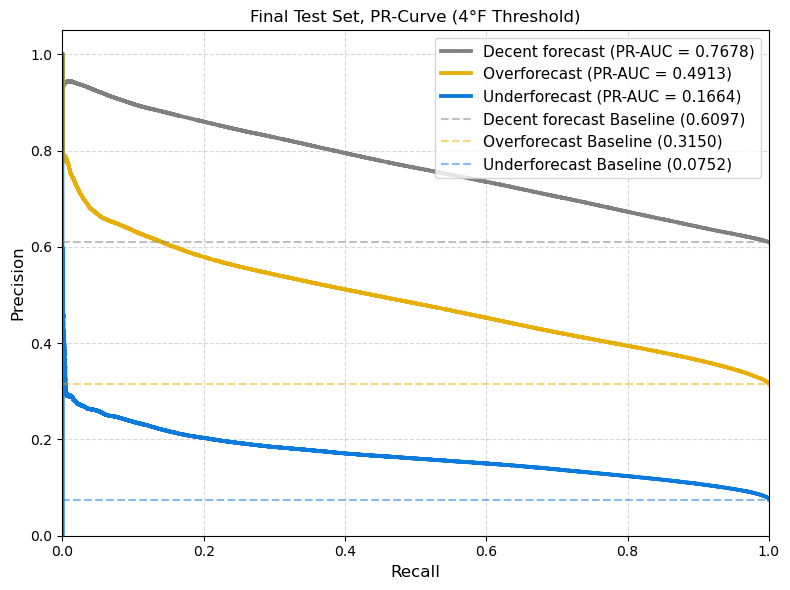

In [17]:
X_test = test_df[features]
y_test = create_multiclass_target(test_df['nbm_minus_obs'], threshold=class_num)

y_test_pred = lgb_model.predict(X_test)
y_test_prob = lgb_model.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
print(f"Final Test Model Accuracy: {test_acc:.4f}")

print("\n--- FINAL LIGHTGBM TEST SET RESULTS ---")
print(classification_report(y_test, y_test_pred, target_names=['Decent Forecast', 'Off overforecast', 'Off underforecast']))

################# plotting
classes = [0, 1, 2]
colors = ['grey', '#e6af09', '#0c7bdc', 'grey']
target_names = ['Decent forecast', 'Overforecast', 'Underforecast']
y_test_binarized = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_test_prob[:, i])
    
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.4f})', linewidth=2.75, color=colors[i])

# baseline reference line
for i in range(len(classes)):
    prevalence = y_test_binarized[:, i].mean()
    plt.axhline(
        y=prevalence, 
        linestyle='--', 
        color=colors[i],
        alpha=0.5,
        label=f'{target_names[i]} Baseline ({prevalence:.4f})'
    )
    
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Final Test Set, PR-Curve ({class_num}°F Threshold)')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
#plt.savefig(f'minT-{class_num}F-lgbm-TEST-final.png')

################# plotting
classes = [0, 1, 2]
colors = ['grey', '#e6af09', '#0c7bdc', 'grey']
target_names = ['Decent forecast', 'Overforecast', 'Underforecast']
y_test_binarized = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_test_prob[:, i])
    
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.4f})', linewidth=2.75, color=colors[i])

# baseline reference line
for i in range(len(classes)):
    prevalence = y_test_binarized[:, i].mean()
    plt.axhline(
        y=prevalence, 
        linestyle='--', 
        color=colors[i],
        alpha=0.5,
        label=f'{target_names[i]} Baseline ({prevalence:.4f})'
    )
    
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Final Test Set, PR-Curve ({class_num}°F Threshold)')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
#plt.savefig(f'minT-{class_num}F-lgbm-TEST-final.png')
plt.show()

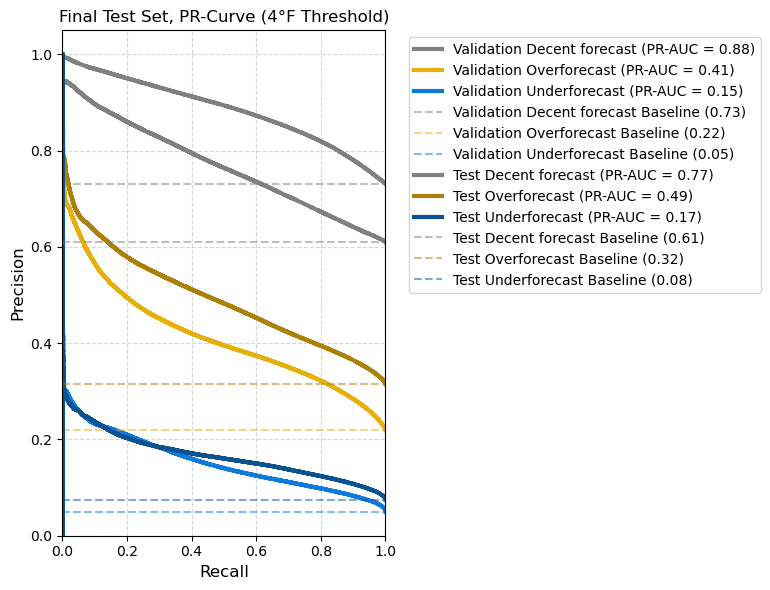

In [28]:
# #plotting
# classes = [0, 1, 2]
# colors = ['grey', '#e6af09', '#0c7bdc', 'grey']
# target_names = ['Validation Decent forecast', 'Validation Overforecast', 'Validation Underforecast']
# y_val_binarized = label_binarize(y_val, classes=classes)

# plt.figure(figsize=(8, 6))

# for i, class_name in enumerate(target_names):
#     precision, recall, _ = precision_recall_curve(y_val_binarized[:, i], y_val_prob[:, i])
    
#     pr_auc = auc(recall, precision)
    
#     plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.2f})', linewidth=3, color=colors[i])

# # baseline reference line
# for i in range(len(classes)):
#     prevalence = y_val_binarized[:, i].mean()
#     plt.axhline(
#         y=prevalence, 
#         linestyle='--', 
#         color=colors[i],
#         alpha=0.5,
#         label=f'{target_names[i]} Baseline ({prevalence:.2f})'
#     )
    
# plt.xlabel('Recall', fontsize=12)
# plt.ylabel('Precision', fontsize=12)
# plt.title(f'LGBM/PR-Curve, {class_num}°F threshold')
# #plt.legend(fontsize=11)
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.tight_layout()
# #plt.savefig(f'minT-{class_num}F-lgbm-pr-auc-final.png')


# ################# plotting
# classes = [0, 1, 2]
# colors = ['grey', '#ad8107', '#0a5291', '#0f0f0f']
# target_names = ['Test Decent forecast', 'Test Overforecast', 'Test Underforecast']
# y_test_binarized = label_binarize(y_test, classes=classes)


# for i, class_name in enumerate(target_names):
#     precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_test_prob[:, i])
    
#     pr_auc = auc(recall, precision)
    
#     plt.plot(recall, precision, label=f'{class_name} (PR-AUC = {pr_auc:.2f})', linewidth=3, color=colors[i])

# # baseline reference line
# for i in range(len(classes)):
#     prevalence = y_test_binarized[:, i].mean()
#     plt.axhline(
#         y=prevalence, 
#         linestyle='--', 
#         color=colors[i],
#         alpha=0.5,
#         label=f'{target_names[i]} Baseline ({prevalence:.2f})'
#     )
    
# plt.xlabel('Recall', fontsize=12)
# plt.ylabel('Precision', fontsize=12)
# plt.title(f'Final Test Set, PR-Curve ({class_num}°F Threshold)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.tight_layout()
# #plt.savefig(f'minT-4F-lgbm-final-presentation.png')
# plt.show()